In [ ]:
# VAE-GAN for 3-class gene expression data
# Classes: CF_CD, MF_CD, H
# Goal:
# - Keep 58205 genes
# - Generate 1000 samples/class → refine → final 100 samples/class

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# LOAD DATA
# -----------------------------

df = pd.read_excel("/Users/apple/Downloads/cd_mf_cf.xlsx")

genes = df.iloc[:, 0]

cf_cd = df.loc[:, "CF_CD1":"CF_CD23"]
mf_cd = df.loc[:, "MF_CD1":"MF_CD23"]
healthy = df.loc[:, "H1":"H13"]

# Transpose → samples × genes
cf_cd = cf_cd.T
mf_cd = mf_cd.T
healthy = healthy.T

# Normalize separately
scalers = {}
data_scaled = {}

for name, data in zip(["cf", "mf", "h"], [cf_cd, mf_cd, healthy]):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    scalers[name] = scaler
    data_scaled[name] = scaled

# -----------------------------
# VAE MODEL
# -----------------------------

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=100):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc21 = nn.Linear(512, latent_dim)
        self.fc22 = nn.Linear(512, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 512)
        self.fc4 = nn.Linear(512, input_dim)
        self.relu = nn.ReLU()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        return self.fc21(h), self.fc22(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.relu(self.fc3(z))
        return self.fc4(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def loss_fn(recon_x, x, mu, logvar):
    recon = nn.functional.mse_loss(recon_x, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl * 1e-5

# -----------------------------
# TRAIN VAE PER CLASS
# -----------------------------

def train_vae(data, epochs=50):
    data_tensor = torch.tensor(data, dtype=torch.float32)
    model = VAE(data.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        recon, mu, logvar = model(data_tensor)
        loss = loss_fn(recon, data_tensor, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    return model

print("Training CF-CD VAE...")
vae_cf = train_vae(data_scaled["cf"])

print("Training MF-CD VAE...")
vae_mf = train_vae(data_scaled["mf"])

print("Training Healthy VAE...")
vae_h = train_vae(data_scaled["h"])

# -----------------------------
# GENERATE 1000 SAMPLES EACH
# -----------------------------

def generate(model, scaler, n=1000):
    z = torch.randn(n, 100)
    samples = model.decode(z).detach().numpy()
    return scaler.inverse_transform(samples)

cf_gen = generate(vae_cf, scalers["cf"], 1000)
mf_gen = generate(vae_mf, scalers["mf"], 1000)
h_gen = generate(vae_h, scalers["h"], 1000)

# -----------------------------
# GAN REFINEMENT
# -----------------------------

class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def refine(data, epochs=50):
    data_tensor = torch.tensor(data, dtype=torch.float32)
    gen = Generator(100, data.shape[1])
    disc = Discriminator(data.shape[1])

    opt_g = optim.Adam(gen.parameters(), lr=1e-4)
    opt_d = optim.Adam(disc.parameters(), lr=1e-4)
    loss = nn.BCELoss()

    for epoch in range(epochs):
        for i in range(0, len(data_tensor), 32):
            real = data_tensor[i:i+32]
            bs = real.size(0)

            z = torch.randn(bs, 100)
            fake = gen(z)

            real_lbl = torch.ones(bs, 1)
            fake_lbl = torch.zeros(bs, 1)

            d_loss = loss(disc(real), real_lbl) + loss(disc(fake.detach()), fake_lbl)

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            g_loss = loss(disc(fake), real_lbl)

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

        print(f"GAN Epoch {epoch+1}, D: {d_loss.item():.4f}, G: {g_loss.item():.4f}")

    z = torch.randn(100, 100)
    refined = gen(z).detach().numpy()
    return refined

cf_final = refine(cf_gen)
mf_final = refine(mf_gen)
h_final = refine(h_gen)

# -----------------------------
# FORMAT OUTPUT
# -----------------------------

genes_clean = genes.astype(str).str.split('.').str[0]

cf_df = pd.DataFrame(cf_final.T)
mf_df = pd.DataFrame(mf_final.T)
h_df = pd.DataFrame(h_final.T)

cf_df.insert(0, "Gene", genes_clean)
mf_df.insert(0, "Gene", genes_clean)
h_df.insert(0, "Gene", genes_clean)

cf_df.columns = ["Gene"] + [f"CF_CD{i}" for i in range(1, 101)]
mf_df.columns = ["Gene"] + [f"MF_CD{i}" for i in range(1, 101)]
h_df.columns = ["Gene"] + [f"H{i}" for i in range(1, 101)]

final_df = pd.concat([
    cf_df,
    mf_df.iloc[:, 1:],
    h_df.iloc[:, 1:]
], axis=1)

final_df.to_csv("synthetic_3class_58205x300.csv", index=False)

print("Done: 3-class synthetic dataset (100 each class)")

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_excel("/Users/apple/Downloads/cd_mf_cf.xlsx")

# Clean column names
df.columns = df.columns.str.strip()

genes = df.iloc[:, 0]

# Robust selection (fixes your error)
cf_cd = df.filter(regex="^CF_CD")
mf_cd = df.filter(regex="^MF_CD")
healthy = df.filter(regex="^H\\d+")

# Transpose → samples × genes
cf_cd = cf_cd.T
mf_cd = mf_cd.T
healthy = healthy.T

# -----------------------------
# NORMALIZATION (for training only)
# -----------------------------
scalers = {}
data_scaled = {}

for name, data in zip(["cf", "mf", "h"], [cf_cd, mf_cd, healthy]):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    scalers[name] = scaler
    data_scaled[name] = scaled

# -----------------------------
# VAE MODEL
# -----------------------------
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=100):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc21 = nn.Linear(512, latent_dim)
        self.fc22 = nn.Linear(512, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 512)
        self.fc4 = nn.Linear(512, input_dim)
        self.relu = nn.ReLU()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        return self.fc21(h), self.fc22(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.fc4(self.relu(self.fc3(z)))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def loss_fn(recon_x, x, mu, logvar):
    recon = nn.functional.mse_loss(recon_x, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl * 1e-5

# -----------------------------
# TRAIN VAE
# -----------------------------
def train_vae(data, epochs=50):
    x = torch.tensor(data, dtype=torch.float32)
    model = VAE(data.shape[1])
    opt = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        recon, mu, logvar = model(x)
        loss = loss_fn(recon, x, mu, logvar)

        opt.zero_grad()
        loss.backward()
        opt.step()

    return model

vae_cf = train_vae(data_scaled["cf"])
vae_mf = train_vae(data_scaled["mf"])
vae_h  = train_vae(data_scaled["h"])

# -----------------------------
# GENERATE 1000 SAMPLES
# -----------------------------
def generate(model, scaler, n=1000):
    z = torch.randn(n, 100)
    samples = model.decode(z).detach().numpy()
    samples = scaler.inverse_transform(samples)
    samples = np.maximum(samples, 0)  # no negative TPM
    return samples

cf_gen = generate(vae_cf, scalers["cf"])
mf_gen = generate(vae_mf, scalers["mf"])
h_gen  = generate(vae_h,  scalers["h"])

# -----------------------------
# GAN REFINEMENT (FIXED)
# -----------------------------
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1)  # NO sigmoid
        )
    def forward(self, x):
        return self.net(x)

def refine(data, epochs=50):
    real_data = torch.tensor(data, dtype=torch.float32)

    gen = Generator(100, data.shape[1])
    disc = Discriminator(data.shape[1])

    opt_g = optim.Adam(gen.parameters(), lr=1e-4)
    opt_d = optim.Adam(disc.parameters(), lr=1e-4)

    loss = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        for i in range(0, len(real_data), 32):
            real = real_data[i:i+32]
            bs = real.size(0)

            z = torch.randn(bs, 100)
            fake = gen(z)

            real_lbl = torch.ones(bs, 1)
            fake_lbl = torch.zeros(bs, 1)

            # Train Discriminator
            d_loss = loss(disc(real), real_lbl) + \
                     loss(disc(fake.detach()), fake_lbl)

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # Train Generator
            g_loss = loss(disc(fake), real_lbl)

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

    # Generate final 100 samples
    z = torch.randn(100, 100)
    refined = gen(z).detach().numpy()
    refined = np.maximum(refined, 0)

    return refined

cf_final = refine(cf_gen)
mf_final = refine(mf_gen)
h_final  = refine(h_gen)

# -----------------------------
# TPM NORMALIZATION (CRITICAL)
# -----------------------------
def tpm_normalize(samples):
    sums = samples.sum(axis=1, keepdims=True)
    sums[sums == 0] = 1
    return (samples / sums) * 1e6

cf_final = tpm_normalize(cf_final)
mf_final = tpm_normalize(mf_final)
h_final  = tpm_normalize(h_final)

# -----------------------------
# FORMAT OUTPUT
# -----------------------------
genes_clean = genes.astype(str).str.split('.').str[0]

cf_df = pd.DataFrame(cf_final.T)
mf_df = pd.DataFrame(mf_final.T)
h_df  = pd.DataFrame(h_final.T)

cf_df.insert(0, "Gene", genes_clean)
mf_df.insert(0, "Gene", genes_clean)
h_df.insert(0, "Gene", genes_clean)

cf_df.columns = ["Gene"] + [f"CF_CD{i}" for i in range(1, 101)]
mf_df.columns = ["Gene"] + [f"MF_CD{i}" for i in range(1, 101)]
h_df.columns  = ["Gene"] + [f"H{i}" for i in range(1, 101)]

final_df = pd.concat([
    cf_df,
    mf_df.iloc[:, 1:],
    h_df.iloc[:, 1:]
], axis=1)

final_df.to_csv("synthetic_3class_58205x300.csv", index=False)

print("Done: TPM-consistent synthetic dataset generated")

Done: TPM-consistent synthetic dataset generated


Data shapes:
CF-CD: (23, 58204)
MF-CD: (23, 58204)
Healthy: (13, 58204)

Training VAEs...
CF-CD Epoch 1/50 Loss: 0.7481
CF-CD Epoch 2/50 Loss: 42638.1797
CF-CD Epoch 3/50 Loss: 133212720.0000
CF-CD Epoch 4/50 Loss: 447212576342802432.0000
CF-CD Epoch 5/50 Loss: 9499928576.0000
CF-CD Epoch 6/50 Loss: 1651547904.0000
CF-CD Epoch 7/50 Loss: 842529374208.0000
CF-CD Epoch 8/50 Loss: 3534421229568.0000
CF-CD Epoch 9/50 Loss: 154072285184.0000
CF-CD Epoch 10/50 Loss: 48321638400.0000
CF-CD Epoch 11/50 Loss: 637994008576.0000
CF-CD Epoch 12/50 Loss: 17887264768.0000
CF-CD Epoch 13/50 Loss: 194870848.0000
CF-CD Epoch 14/50 Loss: 100330672.0000
CF-CD Epoch 15/50 Loss: 1429404.7500
CF-CD Epoch 16/50 Loss: 11937.9922
CF-CD Epoch 17/50 Loss: 5711.1914
CF-CD Epoch 18/50 Loss: 715.6683
CF-CD Epoch 19/50 Loss: 30.1782
CF-CD Epoch 20/50 Loss: 40.1559
CF-CD Epoch 21/50 Loss: 135.1789
CF-CD Epoch 22/50 Loss: 81.4703
CF-CD Epoch 23/50 Loss: 69.1274
CF-CD Epoch 24/50 Loss: 39.2268
CF-CD Epoch 25/50 Loss: 3

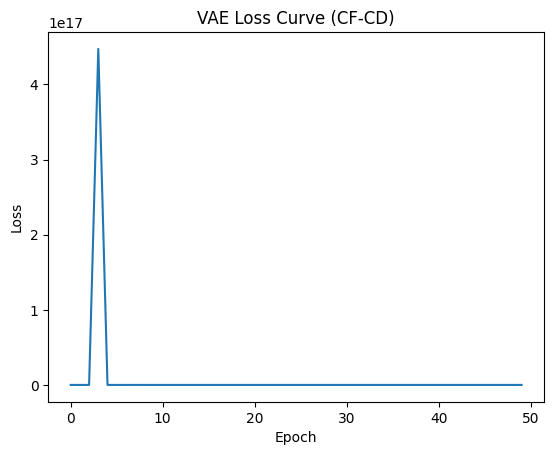

MF-CD Epoch 1/50 Loss: 0.7204
MF-CD Epoch 2/50 Loss: 8111.8989
MF-CD Epoch 3/50 Loss: 16696169.0000
MF-CD Epoch 4/50 Loss: 136482.7500
MF-CD Epoch 5/50 Loss: 3579931648.0000
MF-CD Epoch 6/50 Loss: 5222743040.0000
MF-CD Epoch 7/50 Loss: 188366471168.0000
MF-CD Epoch 8/50 Loss: 206193952.0000
MF-CD Epoch 9/50 Loss: 382590208.0000
MF-CD Epoch 10/50 Loss: 2651774720.0000
MF-CD Epoch 11/50 Loss: 2206633984.0000
MF-CD Epoch 12/50 Loss: 3497234.5000
MF-CD Epoch 13/50 Loss: 2062260.8750
MF-CD Epoch 14/50 Loss: 131788.3906
MF-CD Epoch 15/50 Loss: 3055.8325
MF-CD Epoch 16/50 Loss: 22.7231
MF-CD Epoch 17/50 Loss: 12.9169
MF-CD Epoch 18/50 Loss: 13.4587
MF-CD Epoch 19/50 Loss: 14.5188
MF-CD Epoch 20/50 Loss: 16.3317
MF-CD Epoch 21/50 Loss: 17.0119
MF-CD Epoch 22/50 Loss: 17.6987
MF-CD Epoch 23/50 Loss: 19.1337
MF-CD Epoch 24/50 Loss: 77.4293
MF-CD Epoch 25/50 Loss: 27.3422
MF-CD Epoch 26/50 Loss: 58.1179
MF-CD Epoch 27/50 Loss: 35.1585
MF-CD Epoch 28/50 Loss: 30.7907
MF-CD Epoch 29/50 Loss: 53.663

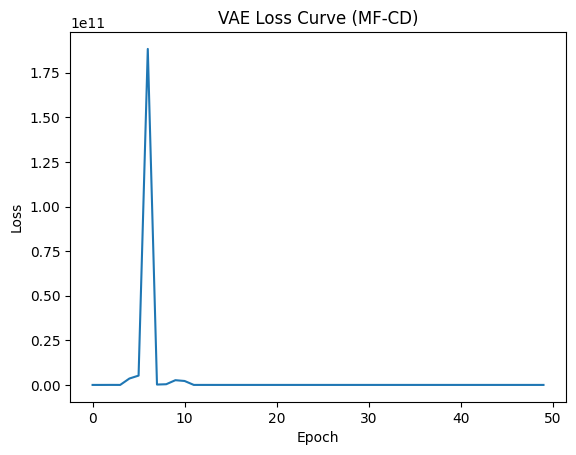

Healthy Epoch 1/50 Loss: 0.6454
Healthy Epoch 2/50 Loss: 2682.8018
Healthy Epoch 3/50 Loss: 21221.6895
Healthy Epoch 4/50 Loss: 106563.2031
Healthy Epoch 5/50 Loss: 867.8069
Healthy Epoch 6/50 Loss: 797.2321
Healthy Epoch 7/50 Loss: 2761.5847
Healthy Epoch 8/50 Loss: 97.5075
Healthy Epoch 9/50 Loss: 9.0988
Healthy Epoch 10/50 Loss: 7.2345
Healthy Epoch 11/50 Loss: 8.5211
Healthy Epoch 12/50 Loss: 7.4775
Healthy Epoch 13/50 Loss: 7.4137
Healthy Epoch 14/50 Loss: 7.2693
Healthy Epoch 15/50 Loss: 6.7693
Healthy Epoch 16/50 Loss: 6.2186
Healthy Epoch 17/50 Loss: 5.6080
Healthy Epoch 18/50 Loss: 5.0620
Healthy Epoch 19/50 Loss: 4.6297
Healthy Epoch 20/50 Loss: 4.1585
Healthy Epoch 21/50 Loss: 3.8557
Healthy Epoch 22/50 Loss: 3.6205
Healthy Epoch 23/50 Loss: 3.4258
Healthy Epoch 24/50 Loss: 3.2693
Healthy Epoch 25/50 Loss: 3.1236
Healthy Epoch 26/50 Loss: 2.9941
Healthy Epoch 27/50 Loss: 2.8581
Healthy Epoch 28/50 Loss: 2.7273
Healthy Epoch 29/50 Loss: 2.5569
Healthy Epoch 30/50 Loss: 2.5360

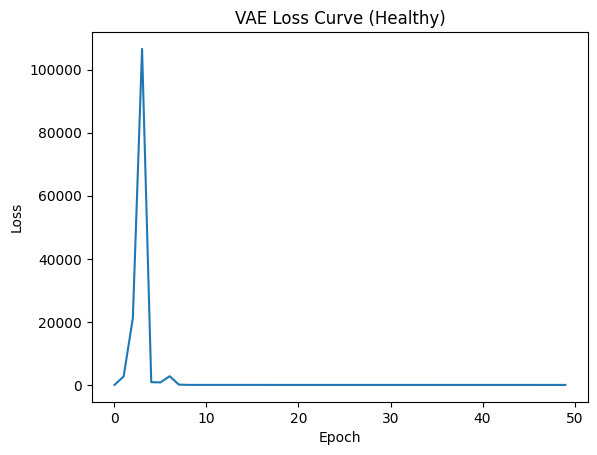


Refining with GAN...
CF-CD GAN Epoch 1: D=0.0217, G=5.0027
CF-CD GAN Epoch 2: D=0.1861, G=2.8064
CF-CD GAN Epoch 3: D=0.0574, G=3.0424
CF-CD GAN Epoch 4: D=0.5165, G=2.7330
CF-CD GAN Epoch 5: D=1.2989, G=2.7301
CF-CD GAN Epoch 6: D=0.0171, G=4.2420
CF-CD GAN Epoch 7: D=0.2036, G=5.0220
CF-CD GAN Epoch 8: D=0.0818, G=7.8491
CF-CD GAN Epoch 9: D=0.0186, G=7.4322
CF-CD GAN Epoch 10: D=0.0585, G=6.0686
CF-CD GAN Epoch 11: D=0.1152, G=5.0563
CF-CD GAN Epoch 12: D=0.0012, G=7.5677
CF-CD GAN Epoch 13: D=0.0181, G=4.6295
CF-CD GAN Epoch 14: D=0.0284, G=4.3882
CF-CD GAN Epoch 15: D=0.0248, G=4.7205
CF-CD GAN Epoch 16: D=0.0147, G=5.2342
CF-CD GAN Epoch 17: D=0.0058, G=5.5830
CF-CD GAN Epoch 18: D=0.0121, G=5.0650
CF-CD GAN Epoch 19: D=0.0044, G=5.9742
CF-CD GAN Epoch 20: D=0.0046, G=5.8465
CF-CD GAN Epoch 21: D=0.0042, G=5.7955
CF-CD GAN Epoch 22: D=0.0043, G=5.6765
CF-CD GAN Epoch 23: D=0.0048, G=5.8366
CF-CD GAN Epoch 24: D=0.0137, G=4.6820
CF-CD GAN Epoch 25: D=0.0144, G=4.6047
CF-CD GAN Ep

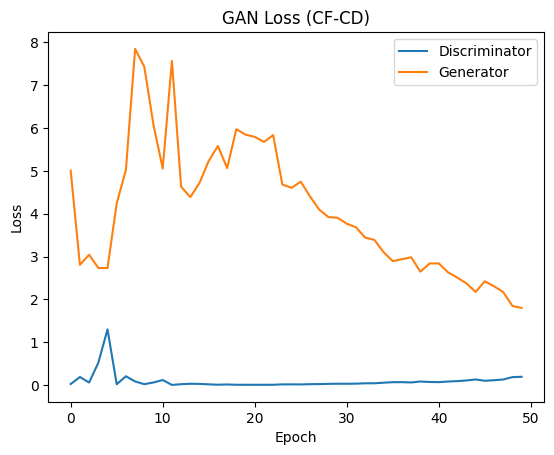

MF-CD GAN Epoch 1: D=0.0211, G=5.0942
MF-CD GAN Epoch 2: D=0.1805, G=3.6491
MF-CD GAN Epoch 3: D=0.2137, G=1.9167
MF-CD GAN Epoch 4: D=0.2153, G=3.4660
MF-CD GAN Epoch 5: D=0.0878, G=5.5923
MF-CD GAN Epoch 6: D=0.0117, G=8.0742
MF-CD GAN Epoch 7: D=0.3742, G=6.6870
MF-CD GAN Epoch 8: D=0.0321, G=5.0784
MF-CD GAN Epoch 9: D=0.0615, G=4.6330
MF-CD GAN Epoch 10: D=0.1333, G=4.1024
MF-CD GAN Epoch 11: D=0.1126, G=3.3577
MF-CD GAN Epoch 12: D=0.1093, G=3.9263
MF-CD GAN Epoch 13: D=0.1274, G=4.5921
MF-CD GAN Epoch 14: D=0.0526, G=4.3776
MF-CD GAN Epoch 15: D=0.0258, G=4.6041
MF-CD GAN Epoch 16: D=0.0169, G=5.3984
MF-CD GAN Epoch 17: D=0.0241, G=4.9728
MF-CD GAN Epoch 18: D=0.0284, G=4.5910
MF-CD GAN Epoch 19: D=0.0230, G=4.9326
MF-CD GAN Epoch 20: D=0.0130, G=5.2351
MF-CD GAN Epoch 21: D=0.0092, G=5.5363
MF-CD GAN Epoch 22: D=0.0129, G=5.0627
MF-CD GAN Epoch 23: D=0.0131, G=5.0408
MF-CD GAN Epoch 24: D=0.0189, G=4.6959
MF-CD GAN Epoch 25: D=0.0155, G=4.9286
MF-CD GAN Epoch 26: D=0.0148, G=4.

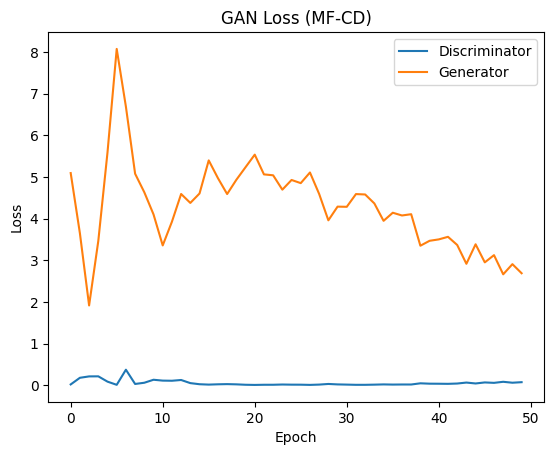

Healthy GAN Epoch 1: D=0.0369, G=4.3450
Healthy GAN Epoch 2: D=0.1987, G=3.3802
Healthy GAN Epoch 3: D=0.0122, G=5.5002
Healthy GAN Epoch 4: D=0.0673, G=4.6611
Healthy GAN Epoch 5: D=0.0183, G=5.9047
Healthy GAN Epoch 6: D=0.0078, G=6.0026
Healthy GAN Epoch 7: D=0.0136, G=5.5685
Healthy GAN Epoch 8: D=0.0211, G=5.4319
Healthy GAN Epoch 9: D=0.0126, G=6.2122
Healthy GAN Epoch 10: D=0.0048, G=6.2313
Healthy GAN Epoch 11: D=0.0060, G=5.7908
Healthy GAN Epoch 12: D=0.0032, G=6.5160
Healthy GAN Epoch 13: D=0.0061, G=5.9741
Healthy GAN Epoch 14: D=0.0035, G=6.1052
Healthy GAN Epoch 15: D=0.0035, G=6.2589
Healthy GAN Epoch 16: D=0.0032, G=6.2078
Healthy GAN Epoch 17: D=0.0054, G=5.4964
Healthy GAN Epoch 18: D=0.0073, G=5.3523
Healthy GAN Epoch 19: D=0.0083, G=5.2729
Healthy GAN Epoch 20: D=0.0102, G=4.9153
Healthy GAN Epoch 21: D=0.0196, G=4.3540
Healthy GAN Epoch 22: D=0.0135, G=4.7092
Healthy GAN Epoch 23: D=0.0139, G=4.5604
Healthy GAN Epoch 24: D=0.0129, G=4.7648
Healthy GAN Epoch 25: D=0

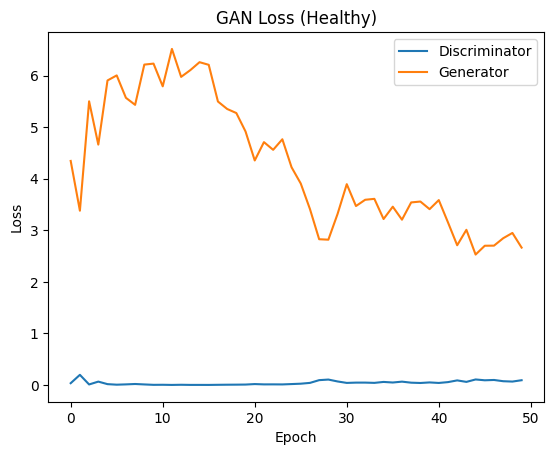


Done: Synthetic TPM dataset generated successfully!


In [2]:
# ============================================================
# VAE-GAN PIPELINE FOR SYNTHETIC RNA-SEQ DATA GENERATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# 1. LOAD AND PREPARE DATA
# ============================================================

# Load dataset

df = pd.read_excel("/Users/apple/Downloads/cd_mf_cf.xlsx")

# Clean column names (remove hidden spaces)
df.columns = df.columns.str.strip()

# Extract gene names
genes = df.iloc[:, 0]

# Select different classes
cf_cd = df.filter(regex="^CF_CD")
mf_cd = df.filter(regex="^MF_CD")
healthy = df.filter(regex="^H\\d+")

# Convert to (samples × genes)
cf_cd = cf_cd.T
mf_cd = mf_cd.T
healthy = healthy.T

print("Data shapes:")
print("CF-CD:", cf_cd.shape)
print("MF-CD:", mf_cd.shape)
print("Healthy:", healthy.shape)

# ============================================================
# 2. NORMALIZATION (FOR MODEL TRAINING ONLY)
# ============================================================

scalers = {}
data_scaled = {}

for name, data in zip(["cf", "mf", "h"], [cf_cd, mf_cd, healthy]):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    scalers[name] = scaler
    data_scaled[name] = scaled

# ============================================================
# 3. DEFINE VAE MODEL
# ============================================================

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=100):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc21 = nn.Linear(512, latent_dim)
        self.fc22 = nn.Linear(512, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 512)
        self.fc4 = nn.Linear(512, input_dim)
        self.relu = nn.ReLU()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        return self.fc21(h), self.fc22(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.fc4(self.relu(self.fc3(z)))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Loss function

def loss_fn(recon_x, x, mu, logvar):
    recon = nn.functional.mse_loss(recon_x, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl * 1e-5

# ============================================================
# 4. TRAIN VAE
# ============================================================

def train_vae(data, epochs=50, title=""):
    x = torch.tensor(data, dtype=torch.float32)
    model = VAE(data.shape[1])
    opt = optim.Adam(model.parameters(), lr=1e-3)

    losses = []

    for epoch in range(epochs):
        recon, mu, logvar = model(x)
        loss = loss_fn(recon, x, mu, logvar)

        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())
        print(f"{title} Epoch {epoch+1}/{epochs} Loss: {loss.item():.4f}")

    # Plot loss
    plt.figure()
    plt.plot(losses)
    plt.title(f"VAE Loss Curve ({title})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    return model

print("\nTraining VAEs...")
vae_cf = train_vae(data_scaled["cf"], title="CF-CD")
vae_mf = train_vae(data_scaled["mf"], title="MF-CD")
vae_h  = train_vae(data_scaled["h"],  title="Healthy")

# ============================================================
# 5. GENERATE SYNTHETIC SAMPLES (1000 EACH)
# ============================================================

def generate(model, scaler, n=1000):
    z = torch.randn(n, 100)
    samples = model.decode(z).detach().numpy()
    samples = scaler.inverse_transform(samples)
    samples = np.maximum(samples, 0)
    return samples

cf_gen = generate(vae_cf, scalers["cf"])
mf_gen = generate(vae_mf, scalers["mf"])
h_gen  = generate(vae_h,  scalers["h"])

# ============================================================
# 6. GAN REFINEMENT (WITH LOSS TRACKING)
# ============================================================

class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x)


def refine(data, epochs=50, title=""):
    real_data = torch.tensor(data, dtype=torch.float32)

    gen = Generator(100, data.shape[1])
    disc = Discriminator(data.shape[1])

    opt_g = optim.Adam(gen.parameters(), lr=1e-4)
    opt_d = optim.Adam(disc.parameters(), lr=1e-4)

    loss_fn = nn.BCEWithLogitsLoss()

    d_losses, g_losses = [], []

    for epoch in range(epochs):
        for i in range(0, len(real_data), 32):
            real = real_data[i:i+32]
            bs = real.size(0)

            z = torch.randn(bs, 100)
            fake = gen(z)

            real_lbl = torch.ones(bs, 1)
            fake_lbl = torch.zeros(bs, 1)

            # Discriminator
            d_loss = loss_fn(disc(real), real_lbl) + \
                     loss_fn(disc(fake.detach()), fake_lbl)

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # Generator
            g_loss = loss_fn(disc(fake), real_lbl)

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())

        print(f"{title} GAN Epoch {epoch+1}: D={d_loss.item():.4f}, G={g_loss.item():.4f}")

    # Plot GAN losses
    plt.figure()
    plt.plot(d_losses, label="Discriminator")
    plt.plot(g_losses, label="Generator")
    plt.legend()
    plt.title(f"GAN Loss ({title})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    z = torch.randn(100, 100)
    refined = gen(z).detach().numpy()
    return np.maximum(refined, 0)

print("\nRefining with GAN...")
cf_final = refine(cf_gen, title="CF-CD")
mf_final = refine(mf_gen, title="MF-CD")
h_final  = refine(h_gen,  title="Healthy")

# ============================================================
# 7. TPM NORMALIZATION
# ============================================================

def tpm_normalize(samples):
    sums = samples.sum(axis=1, keepdims=True)
    sums[sums == 0] = 1
    return (samples / sums) * 1e6

cf_final = tpm_normalize(cf_final)
mf_final = tpm_normalize(mf_final)
h_final  = tpm_normalize(h_final)

# ============================================================
# 8. FORMAT FINAL OUTPUT
# ============================================================

genes_clean = genes.astype(str).str.split('.').str[0]

cf_df = pd.DataFrame(cf_final.T)
mf_df = pd.DataFrame(mf_final.T)
h_df  = pd.DataFrame(h_final.T)

cf_df.insert(0, "Gene", genes_clean)
mf_df.insert(0, "Gene", genes_clean)
h_df.insert(0, "Gene", genes_clean)

cf_df.columns = ["Gene"] + [f"CF_CD{i}" for i in range(1, 101)]
mf_df.columns = ["Gene"] + [f"MF_CD{i}" for i in range(1, 101)]
h_df.columns  = ["Gene"] + [f"H{i}" for i in range(1, 101)]

final_df = pd.concat([
    cf_df,
    mf_df.iloc[:, 1:],
    h_df.iloc[:, 1:]
], axis=1)

final_df.to_csv("synthetic_3class_58205x300(1).csv", index=False)

print("\nDone: Synthetic TPM dataset generated successfully!")